# Module 3.3 — Notebook B: Improve the baseline

In **Notebook A** you evaluated whether Candlekeep’s routing prototype was strong enough for the next MVP step.

Here you take the next step:

> If the baseline is weak, can we improve it in practical ways?

You will try realistic levers: 
- **better prompt design**, 
- **few-shot examples**, 
- an **optional multi-model comparison** with the improved prompt, 
- and **deeper diagnostics**.

The goal is not perfect scores. The goal is to see **what actually helps**, what **trade-offs** appear (cost, latency, safety), and whether the prototype is moving closer to MVP viability.

## What this notebook explores

This notebook focuses on **improvement**, not initial validation.

1. **Prompt refinement** — Can clearer instructions improve routing quality?
2. **Few-shot learning** — Do labeled examples help the model route better?
3. **Trade-offs** — Do improvements change cost or latency?
4. **Diagnostics** — Where does the model still fail, and why?

Assume you have completed Notebook A (or at least have a comparable baseline). You’ll use the **same dataset** and compare every change to that reference.

## Setup

Install dependencies and load helpers. Run the cell below, then move on to **Settings**.

- **Colab:** the cell installs from GitHub automatically.
- **Local:** replace the install line with `%pip install -q -e .` (from the repo root).

Keep your API key in **Secrets** (Colab) or a local **`.env`** file — never commit real keys.

In [16]:
%pip install -q git+https://github.com/mnrozhkov/ai_leader.git
%matplotlib inline

import os

from dotenv import load_dotenv

from ai_leader import *

load_dotenv(override=False)

/Users/mnrozhkov/dev/ai-leader/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


True

## Step 1 — Settings

Set your API key and experiment parameters below. The model and dataset should match what you used in Notebook A so comparisons are meaningful.

### API key & parameters

This notebook calls the **Nebius inference API** (OpenAI-compatible).
Get your key at [Nebius AI Studio](https://studio.nebius.ai) → Settings → API Keys.
Store it as a Colab Secret named `NEBIUS_API_KEY`, or add it to a local `.env` file — do **not** paste a real key into the notebook.

**401 error?** Make sure you use a Nebius *inference* API key (not an OpenAI key). See [Nebius API authentication](https://docs.nebius.com/studio/api/authentication) for regional endpoint options.

In [17]:
api_key = setup_api_key()

# Dataset — replace with your own CSV URL or local path to use different data
DATASET_URL = os.getenv(
    "AI_LEADER_DATASET_PATH",
    "https://docs.google.com/spreadsheets/d/e/2PACX-1vSU5zvx8wgk9FMEcRGlCtXkE4_T90OgsrqU4QPNZC478Rsp5JEBEEUjvlMkY3iMoiAmpa1zQ5QFkgT5/pub?output=csv",
)

### Load the dataset

Load the **same labeled evaluation dataset** used in Notebook A (same default URL in Settings, or the same `AI_LEADER_DATASET_PATH` if you pointed it at a local `.csv`).

Reusing the same data is important: it makes baseline vs improved comparisons meaningful instead of mixing dataset effects with model/prompt effects.

In [18]:
df = load_and_validate_dataset(DATASET_URL)
print(f"Rows loaded: {len(df)}")
df.head(3)

Rows loaded: 100


,Request Text,Submission Channel,Related to order,Order ID,Category,Routing to Department,Timestamp,Order History,row_id
0,My Autumn Oak table arrived with a cracked leg...,Email,True,CK-8821,Order Issue,Returns,2025-10-01 09:12:00,2025-09-24 — Order placed | 2025-09-25 — Shipp...,0
1,I need to change my address for order CK-9902....,Chat,True,CK-9902,Delivery,Logistics,2025-09-19 14:00:00,2025-09-12 — Order placed | 2025-09-14 — Shipp...,1
2,Where is my package? The tracking says DPD has...,Social,True,CK-1102,Delivery,Logistics,2025-10-01 10:15:00,2025-09-24 — Order placed | 2025-09-26 — Shipp...,2


**Optional:** department distribution in gold labels.

## Step 2 — Baseline reference run

First, select the model you chose in Notebook A and run the baseline prompt. This is the reference point for all later comparisons.


In [19]:
# Best model from Notebook A — change if your evaluation picked a different one
MODEL_TO_EVALUATE = "openai/gpt-oss-120b"
client = create_client(api_key, model=MODEL_TO_EVALUATE)

In [20]:
baseline_run = await evaluate_model_on_dataframe_async(
    df=df,
    model=MODEL_TO_EVALUATE,
    client=client,
    system_prompt=DEFAULT_SYSTEM_PROMPT,
)

Running openai/gpt-oss-120b:   0%|          | 0/100 [00:00<?, ?row/s]

Check the baseline results before changing anything. Note which dimensions fail — that tells you which improvement to try first.

In [21]:
baseline_decision = evaluate_decision(baseline_run)
display_mvp_decision(decision=baseline_decision)

,Dimension,Status,Value,Pass threshold (≤)
0,Department Accuracy,fail,0.610,0.85
1,Category Accuracy,fail,0.680,0.85
2,Unsafe Auto Route Rate,fail,0.370,0.03
3,Monthly Cost Usd,pass,3.364,1000.00
4,P95 Latency Ms,pass,1438.740,5000.00


**What to expect:**
- The baseline will likely fail one or more dimensions — that is the starting point, not the verdict.
- **Quality fail** → improving the prompt (Step 3) is the highest-leverage next step.
- **Safety fail** → the model’s confidence is likely poorly calibrated; inspect high-confidence errors in Step 4.
- **Cost fail** → consider a lighter model.

## Step 3 — Improve the prompt

Can a better prompt improve routing quality? We run the **improved prompt** on the same data and model, then compare it to the baseline.

Any change in accuracy, safety, or cost is attributable to the prompt alone — everything else stays fixed.

In [22]:
improved_prompt_run = await evaluate_model_on_dataframe_async(
    df=df,
    model=MODEL_TO_EVALUATE,
    client=client,
    system_prompt=IMPROVED_SYSTEM_PROMPT,
)

Running openai/gpt-oss-120b:   0%|          | 0/100 [00:00<?, ?row/s]

In [23]:
improved_prompt_decision = evaluate_decision(improved_prompt_run)
display_mvp_decision(decision=improved_prompt_decision)

,Dimension,Status,Value,Pass threshold (≤)
0,Department Accuracy,fail,0.710,0.85
1,Category Accuracy,fail,0.820,0.85
2,Unsafe Auto Route Rate,fail,0.270,0.03
3,Monthly Cost Usd,pass,4.731,1000.00
4,P95 Latency Ms,pass,1559.696,5000.00


In [24]:
_ = display_run_comparison_table(
    baseline=baseline_run,
    new=improved_prompt_run,
    eval_df=df,
    new_label="Improved prompt",
    show_all=False,
)

,baseline,Improved prompt,delta_vs_baseline
department_accuracy,0.61,0.71,0.100
category_accuracy,0.68,0.82,0.140
unsafe_auto_route_rate,0.37,0.27,-0.100
monthly_cost_usd,3.364,4.731,1.367
p95_latency_ms,1438.74,1559.696,120.956


**What to look for in the comparison:**
- Did **department accuracy** and **category accuracy** improve? By how much?
- Did the **unsafe auto-route rate** decrease (safer) or increase (riskier)?
- Did cost or latency change significantly? Small increases are expected with a longer prompt.
- Look at the `delta_vs_baseline` column -- positive deltas in accuracy and negative deltas in cost/latency are improvements.

## Step 4 — Analyze mistakes and fix annotations

Where does the model still get it wrong? In this step we:
1. Look at the most common mistakes from Step 3.
2. Inspect **high-confidence errors** — cases where the model was confident but wrong.
3. Fix ambiguous or incorrect gold labels in the dataset.
4. Re-evaluate and compare with the previous run.

In [25]:
mistake_examples = await prepare_mistake_examples(
    eval_df=df,
    predictions=improved_prompt_run.predictions,
    max_per_type=3,
)

display(mistake_examples.head(10))

,type,request_text,gold_category,predicted_category,gold_department,predicted_department
0,category,Website is crashing on the payment screen.,General Feedback,Payment,Product Team,Customer Support
1,category,I am going to sue your company if you don't fi...,Delivery,Order Issue,Logistics,Returns
2,category,Refund the holiday wreath. It looks cheap.,Order Issue,Payment,Returns,Customer Support
3,department,The toaster oven sparked when I plugged it in....,Order Issue,Order Issue,Product Team,Returns
4,department,Instructions for the Lumina lamp are missing f...,Order Issue,Order Issue,Product Team,Returns
5,department,Website is crashing on the payment screen.,General Feedback,Payment,Product Team,Customer Support


**What to look for:** scan the mistake examples above. Are the errors random, or do you see a pattern (e.g. the model consistently confuses Returns with Customer Support)? Patterns suggest the prompt or labels need targeted fixes.

#### High-confidence errors (calibration check)

Review cases where the model said `Confidence == "High"` but routed to the wrong department.
If this set is large, confidence is likely **poorly calibrated** (the model is overconfident).

Use these rows to tighten confidence rules before re-testing.
Also note: some examples can be **data-label issues** (ambiguous or mis-annotated gold labels), so treat this review as model+data quality learning.

In [26]:
high_conf_errors_df = display_high_confident_errors(
    eval_df=df,
    predictions=improved_prompt_run.predictions,
    max_rows=10,
)

High-confidence department errors: 27
Error rate within High-confidence predictions: 27.6%
Reminder: some rows may indicate labeling ambiguity/data issues, not only model issues.


,row_id,Request Text,Category,Department,Predicted Category,Predicted Department,Confidence
4,4,The toaster oven sparked when I plugged it in....,Order Issue,Product Team,Order Issue,Returns,High
8,8,Instructions for the Lumina lamp are missing f...,Order Issue,Product Team,Order Issue,Returns,High
13,13,Website is crashing on the payment screen.,General Feedback,Product Team,Payment,Customer Support,High
19,19,I am going to sue your company if you don't fi...,Delivery,Logistics,Order Issue,Returns,High
23,23,Refund the holiday wreath. It looks cheap.,Order Issue,Returns,Payment,Customer Support,High
26,26,Package in rain rug ruined.,Delivery,Logistics,Order Issue,Returns,High
29,29,Talk to manager now. Support is useless.,Delivery,Logistics,General Feedback,Product Team,High
32,32,No refund received for return CK-9944.,Payment,Returns,Payment,Customer Support,High
33,33,Sage green curtains are actually grey.,Order Issue,Returns,General Feedback,Product Team,High
35,35,Order canceled without my permission.,Order Issue,Customer Support,Order Issue,Returns,High


#### Re-annotation candidates (top 10)

Export 10 high-confidence errors to `fixed-annotation.json` for manual review.
This creates a small queue of examples to verify/correct gold labels before re-testing.

- Allowed Department: Logistics, Customer Support, Product Team, Returns
- Allowed Category: Delivery, Order Issue, General Feedback, Payment

In [27]:
analyzed_high_conf_df = analyze_high_confident_errors(high_conf_errors_df)

llm_review_df = await recommend_new_labels(
    analyzed_high_conf_df,
    client=client,
    model=MODEL_TO_EVALUATE,
)

revise_df = llm_review_df.loc[llm_review_df["Revise labels"]].head(10)
print(f"LLM relabel recommendations analyzed: {len(llm_review_df)}")
print(f"Rows flagged for revision: {int(llm_review_df['Revise labels'].sum())}")
display(revise_df.head(3))

LLM relabel analysis:   0%|          | 0/10 [00:00<?, ?item/s]

LLM relabel recommendations analyzed: 10
Rows flagged for revision: 5


NameError: name 'pd' is not defined

#### Apply label fixes

Based on the review above, correct the gold labels for ambiguous or mis-annotated rows, then re-evaluate to see if the fixes improve results.

In [ ]:
revised_labels = [
    {"row_id": 4, "new_category": "General Feedback"},
    {"row_id": 13, "new_category": "Payment"},
    {"row_id": 26, "new_department": "Returns"},
    {"row_id": 33, "new_category": "General Feedback", "new_department": "Product Team"},
    {"row_id": 40, "new_category": "Order Issue", "new_department": "Returns"},
    {"row_id": 57, "new_category": "General Feedback", "new_department": "Product Team"},
    {"row_id": 65, "new_category": "General Feedback"},
    {"row_id": 83, "new_category": "General Feedback", "new_department": "Product Team"},
    {"row_id": 88, "new_category": "Delivery", "new_department": "Logistics"},
    {"row_id": 90, "new_category": "General Feedback", "new_department": "Product Team"},
    {"row_id": 94, "new_department": "Logistics"},
    {"row_id": 95, "new_category": "Delivery", "new_department": "Logistics"},
    {"row_id": 99, "new_department": "Logistics"},
]

# Apply recommended labels
df = apply_revised_labels(df, revised_labels)

# Check that the labels were updated correctly
df.loc[df["row_id"] == 4, "Category"]

4    General Feedback
Name: Category, dtype: str

In [ ]:
revised_labels_run = await evaluate_model_on_dataframe_async(
    df=df,
    model=MODEL_TO_EVALUATE,
    client=client,
    system_prompt=IMPROVED_SYSTEM_PROMPT,
)

Running openai/gpt-oss-120b:   0%|          | 0/100 [00:00<?, ?row/s]

In [ ]:
revised_labels_decision = evaluate_decision(revised_labels_run)
display_mvp_decision(decision=revised_labels_decision)

,Dimension,Status,Value,Pass threshold (≤)
0,Department Accuracy,fail,0.780,0.85
1,Category Accuracy,pass,0.870,0.85
2,Unsafe Auto Route Rate,fail,0.170,0.03
3,Monthly Cost Usd,pass,4.667,1000.00
4,P95 Latency Ms,pass,2749.581,5000.00


In [ ]:
_ = display_run_comparison_table(
    baseline=improved_prompt_run,
    new=revised_labels_run,
    eval_df=df,
    new_label="Fix data annotation",
)

,baseline,Fix data annotation,delta_vs_baseline
department_accuracy,0.7,0.78,0.080
category_accuracy,0.83,0.87,0.040
unsafe_auto_route_rate,0.2,0.17,-0.030
monthly_cost_usd,4.635,4.667,0.032
p95_latency_ms,2364.467,2749.581,385.114


**What to look for:** did fixing the labels improve accuracy? Even small gains confirm that some "errors" were actually label noise, not model mistakes. This is a common finding — data quality improvements help every downstream approach.

## Step 5 — Few-shot trade-offs

Do labeled examples in the prompt help? We run the same model with **0, 2, 4, 8, and 16 few-shot examples** and compare quality, cost, and latency.

The goal is to find the point where adding more examples **stops helping** (diminishing returns) relative to the cost and latency increase.

In [ ]:
N_SHOT_VALUES = [0, 2, 4, 8, 16]

ablation_config = FewShotAblationConfig(
    best_model=MODEL_TO_EVALUATE,
    few_shot_counts=N_SHOT_VALUES,
    ablation_random_state=42,
    few_shot_pool_n=32,
    ablation_eval_n=68,
)

few_shot_pool_df, eval_df_fixed, few_shot_counts = prepare_few_shot_ablation_slice(
    df,
    config=ablation_config,
)

ablation_df, _phase2_predictions = await run_few_shot_ablation_async(
    few_shot_pool_df=few_shot_pool_df,
    eval_df_fixed=eval_df_fixed,
    few_shot_counts=few_shot_counts,
    best_model=MODEL_TO_EVALUATE,
    client=client,
    system_prompt=DEFAULT_SYSTEM_PROMPT,
    show_progress=True,
)

ablation_default_columns = [
    "n_shot",
    "department_accuracy",
    "category_accuracy",
    "cost_total_usd",
    "p95_latency_ms",
]
display(ablation_df[[c for c in ablation_default_columns if c in ablation_df.columns]])

Few-shot ablation slice: pool=32 rows, fixed eval=68 rows, model=openai/gpt-oss-120b


[Few-shot 1/5] gpt-oss-120b  n_shot=0  eval=68:   0%|          | 0/68 [00:00<?, ?row/s]

[Few-shot 2/5] gpt-oss-120b  n_shot=2  eval=68:   0%|          | 0/68 [00:00<?, ?row/s]

[Few-shot 3/5] gpt-oss-120b  n_shot=4  eval=68:   0%|          | 0/68 [00:00<?, ?row/s]

[Few-shot 4/5] gpt-oss-120b  n_shot=8  eval=68:   0%|          | 0/68 [00:00<?, ?row/s]

[Few-shot 5/5] gpt-oss-120b  n_shot=16  eval=68:   0%|          | 0/68 [00:00<?, ?row/s]

,n_shot,department_accuracy,category_accuracy,cost_total_usd,p95_latency_ms
0,0,0.558824,0.750000,0.011510,1914.485531
1,2,0.720588,0.647059,0.013388,2923.451077
2,4,0.750000,0.838235,0.013353,2598.863502
3,8,0.867647,0.911765,0.015408,2385.116787
4,16,0.779412,0.897059,0.023764,1885.795014


### Visualize few-shot trade-offs

The charts below show how accuracy, cost, and latency change as we add more examples.

In [28]:
_ = plot_metrics_for_n_shot(ablation_df, best_model=MODEL_TO_EVALUATE)
_ = plot_latency_for_n_shots(ablation_df, best_model=MODEL_TO_EVALUATE)

NameError: name 'ablation_df' is not defined

**What to look for:**
- Does accuracy keep rising with more examples, or does it flatten after a certain point?
- How much does cost increase? Few-shot examples add tokens to every request.
- Does latency grow noticeably? Longer prompts mean slower responses.
- The sweet spot is where accuracy gains flatten but cost/latency are still acceptable.

### Run with the best few-shot count

Based on the charts above, pick the `n_shot` value with the best accuracy-to-cost balance and run a full evaluation.

In [ ]:
# Choose best n_shot from ablation (priority: department accuracy, then category accuracy).
best_n = 8
print(f"Selected best n_shot = {best_n}")

Selected best n_shot = 8


In [ ]:
best_n_run = await evaluate_model_on_dataframe_async(
    df=df,
    model=MODEL_TO_EVALUATE,
    client=client,
    system_prompt=IMPROVED_SYSTEM_PROMPT,
)

Running openai/gpt-oss-120b:   0%|          | 0/100 [00:00<?, ?row/s]

In [ ]:
best_n_decision = evaluate_decision(best_n_run)
display_mvp_decision(decision=best_n_decision)

,Dimension,Status,Value,Pass threshold (≤)
0,Department Accuracy,fail,0.780,0.85
1,Category Accuracy,pass,0.870,0.85
2,Unsafe Auto Route Rate,fail,0.190,0.03
3,Monthly Cost Usd,pass,4.631,1000.00
4,P95 Latency Ms,pass,2732.085,5000.00


In [ ]:
# Compare best n-shot with revised labels run

_ = display_run_comparison_table(
    baseline=revised_labels_run,
    new=best_n_run,
    eval_df=df,
    new_label=f"Few-shot best n={best_n}",
)

,baseline,Few-shot best n=8,delta_vs_baseline
department_accuracy,0.78,0.78,0.000
category_accuracy,0.87,0.87,0.000
unsafe_auto_route_rate,0.17,0.19,0.020
monthly_cost_usd,4.667,4.631,-0.036
p95_latency_ms,2749.581,2732.085,-17.496


### Deeper analysis

What mistakes remain after all improvements? The diagnostics below show recurring department confusions to guide further iteration.

category_accuracy           0.870
category_f1_macro           0.872
department_accuracy         0.780
department_f1_macro         0.776
exact_route_match_rate      0.760
misroute_rate               0.220
row_count                 100.000


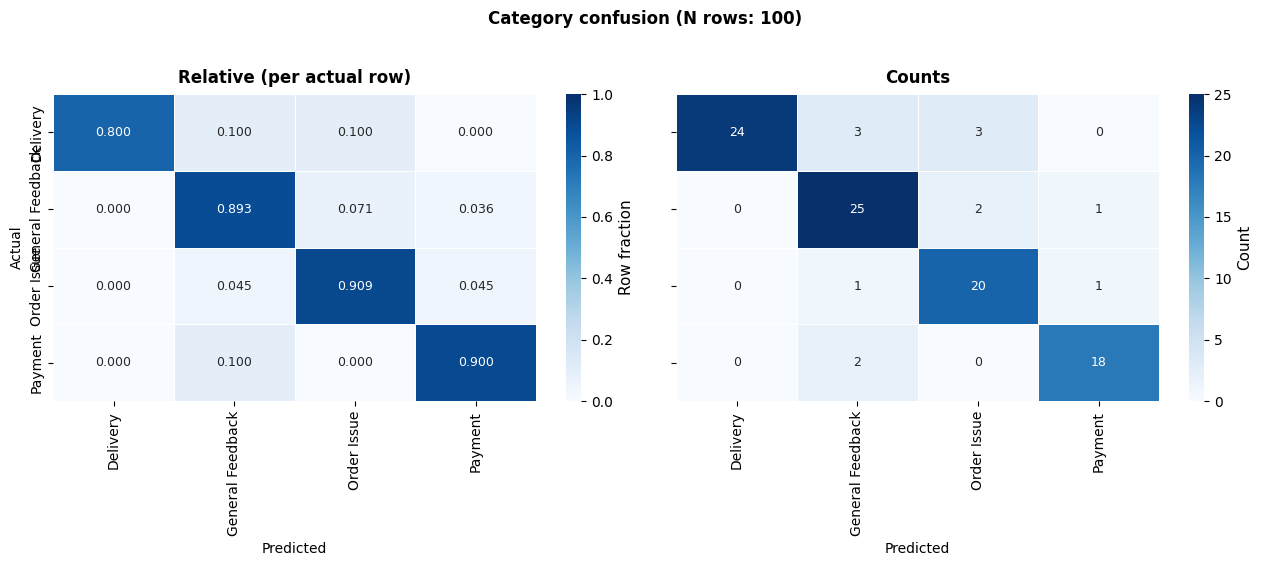

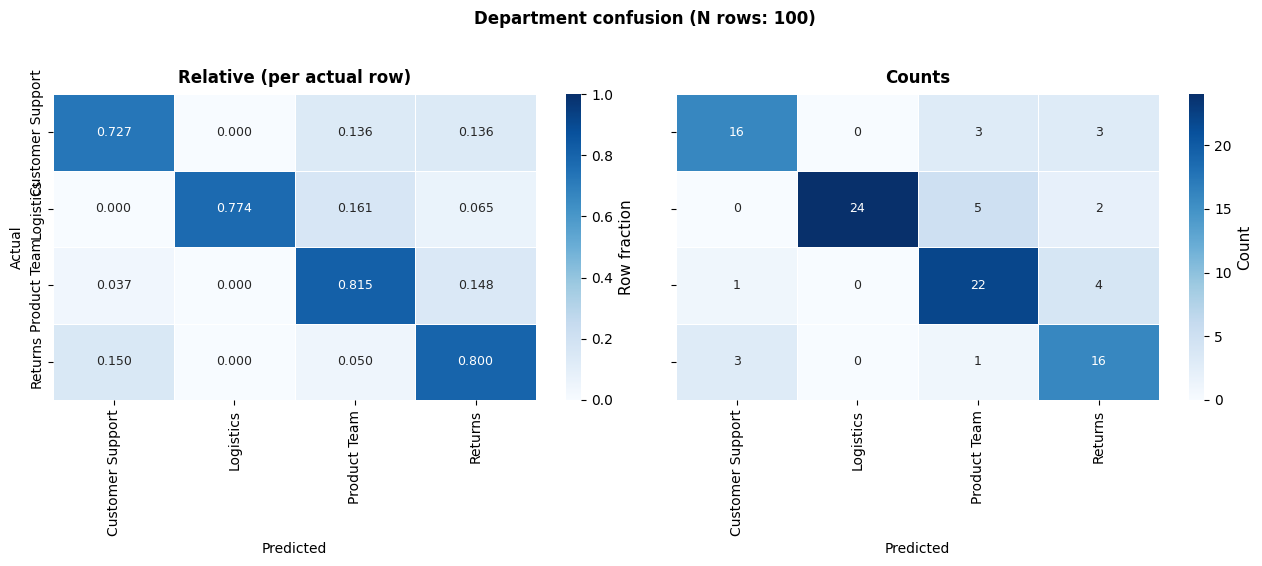

In [ ]:
mistakes = display_evaluation_with_department_mistakes(
    eval_results=best_n_run,
    eval_df=df,
    max_rows=10,
)

## Summary

We tested three practical levers to improve the baseline:

1. **Prompt improvement** — clearer instructions led to better routing accuracy.
2. **Data quality** — fixing ambiguous/incorrect labels removed noise from the evaluation.
3. **Few-shot examples** — adding labeled examples to the prompt can boost accuracy, but with cost/latency trade-offs.

**Key takeaways:**
- These levers are **not exclusive** — combine them for the best results.
- Data quality is foundational: better labels improve every downstream approach.
- Compare each approach against the same baseline to isolate what actually helps.
- Choose the configuration with the best quality/safety improvement at acceptable cost and speed.